### 0️. Importar Librerias

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.graphics.tsaplots import (plot_acf,plot_pacf)

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [3]:
from framework import sp_carga_exploracion as sc
from framework import sp_series_temporales as st

### 1️. Cargar DataFrame / modelos

#### Carga

In [4]:
df = st.cargar_csv(
    '../data/raw/estudiantes_series_temporales.csv',
    parse_dates=['fecha']
)

df.info()

CSV CARGADO
Archivo: ../data/raw/estudiantes_series_temporales.csv
Filas:   36
Columnas: 5
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 36 non-null     datetime64[us]
 1   nota_media            36 non-null     float64       
 2   asistencia_media      36 non-null     float64       
 3   horas_estudio_medias  36 non-null     float64       
 4   tasa_aprobados        36 non-null     float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 1.5 KB


#### check_continuity

In [5]:
st.check_continuity(
    df,
    'fecha'
)

fecha
31 days    20
30 days    12
28 days     2
29 days     1
Name: count, dtype: int64

✅ No hay anomalías evidentes
✅ No parece haber huecos temporales
✅ La secuencia mensual es coherente

La comprobación de continuidad temporal indica que la serie mantiene una secuencia mensual consistente.

Las diferencias observadas entre fechas corresponden a la duración natural de los meses (28, 29, 30 y 31 días), por lo que no se identifican interrupciones ni huecos temporales significativos.

La serie se considera adecuada para continuar con el análisis temporal.

#### fill_date_gaps

In [6]:
df = st.fill_date_gaps(
    df,
    'fecha',
    frecuencia='MS'
)

In [7]:
df.sample(5)

,nota_media,asistencia_media,horas_estudio_medias,tasa_aprobados
fecha,,,,
2024-03-01,73.3,77.1,9.6,0.89
2024-11-01,76.3,80.0,10.6,0.92
2024-04-01,73.8,77.5,9.8,0.90
2024-05-01,74.2,77.9,9.9,0.90
2025-01-01,77.2,80.8,10.9,0.93


La serie se transforma correctamente a frecuencia mensual mediante `MS` (Month Start).

Tras la comprobación de continuidad temporal y la aplicación de `fill_date_gaps()`, no se detectan meses faltantes en la secuencia temporal.

La serie queda preparada para el análisis temporal y puede considerarse completa para el periodo comprendido entre enero de 2023 y diciembre de 2025.
``

¿Por qué elegimos nota_media?

Porque:

✅ Es la variable más importante del proyecto.

In [8]:
serie = df['nota_media']

st.adf_test(serie)

ADF Statistic: 0.9124
p-value:       0.9932
-> La serie NO es estacionaria (p >= 0.05).
   Valora diferenciarla (aumentar 'd' en ARIMA) antes de modelar.


{'ADF Statistic': np.float64(0.912353455134775),
 'p-value': np.float64(0.9932494429710548),
 'estacionaria': np.False_}

La serie temporal de `nota_media` no es estacionaria.

El resultado del test ADF arroja un p-value de 0.9932, muy superior al umbral habitual de significación (0.05), por lo que no se puede rechazar la hipótesis nula de no estacionariedad.

Este comportamiento era esperable, ya que la serie presenta una tendencia creciente clara a lo largo del periodo analizado.

Antes de entrenar modelos ARIMA será necesario eliminar dicha tendencia mediante diferenciación, lo cual se refleja posteriormente en el parámetro `d` del modelo.

#### descomponer_serie

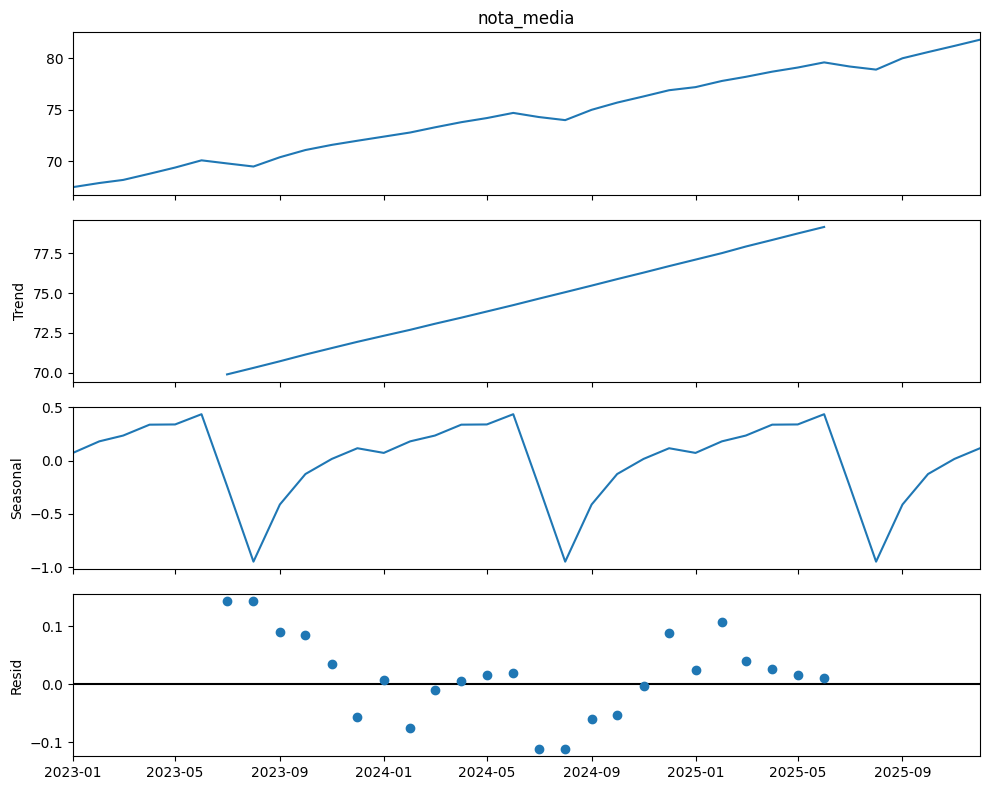

In [10]:
st.descomponer_serie(
    serie,
    periodo=12
)

Hallazgos

La descomposición temporal permite separar la serie en:

- Tendencia.
- Estacionalidad.
- Residuos.

Se observa una tendencia creciente sostenida en la nota media desde 2023 hasta 2025.

Además, aparece un patrón estacional que se repite aproximadamente cada 12 meses, lo que sugiere la existencia de un componente anual.

Los residuos muestran una variabilidad reducida, indicando que gran parte del comportamiento de la serie queda explicado por la tendencia y la estacionalidad.

Conclusiones

La serie no es estacionaria debido a la fuerte tendencia creciente observada.

La presencia de estacionalidad anual sugiere que modelos estacionales como SARIMA podrían resultar adecuados para el forecasting.

La estructura observada indica una serie relativamente predecible y con bajo nivel de ruido.

#### graficos_autocorrelacion

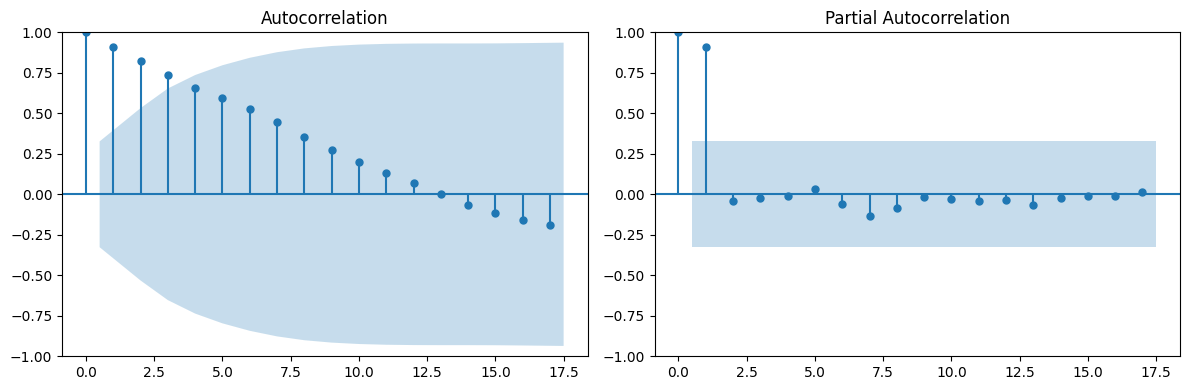

In [11]:
st.graficos_autocorrelacion(
    serie
)

Hallazgos

Los gráficos ACF y PACF muestran una fuerte dependencia temporal entre observaciones consecutivas.

La función de autocorrelación (ACF) presenta valores elevados en los primeros retardos y una disminución progresiva, indicando persistencia temporal.

La función de autocorrelación parcial (PACF) muestra un pico significativo en el primer retardo y una reducción brusca en los siguientes.

Conclusiones

La serie parece depender principalmente de la observación inmediatamente anterior.

Los gráficos sugieren un posible componente autorregresivo de primer orden (AR(1)).

Junto con el resultado

### 3. Train/Test

#### train_test_ts

In [12]:
train, test = st.train_test_ts(
    serie,
    test_size=0.2
)


In [13]:
print(train.shape)
print(test.shape)

print(train.index.min())
print(train.index.max())

print(test.index.min())
print(test.index.max())

(28,)
(8,)
2023-01-01 00:00:00
2025-04-01 00:00:00
2025-05-01 00:00:00
2025-12-01 00:00:00


La división temporal se realiza respetando completamente la secuencia cronológica de los datos.

El conjunto de entrenamiento contiene las observaciones comprendidas entre enero de 2023 y abril de 2025, mientras que el conjunto de prueba agrupa los últimos ocho meses disponibles (mayo de 2025 a diciembre de 2025).

Este enfoque evita fugas de información futuras y reproduce un escenario real de forecasting, donde las predicciones siempre se realizan utilizando únicamente información histórica.
``

### 4. Entrenamiento

#### entrenar_arima

In [14]:
modelo_arima = st.entrenar_arima(
    train,
    order=(1, 1, 1)
)

modelo_arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             nota_media   No. Observations:                   28
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -12.949
Date:                Fri, 02 Oct 2026   AIC                             31.899
Time:                        19:44:59   BIC                             35.786
Sample:                    01-01-2023   HQIC                            33.055
                         - 04-01-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0908      0.296      0.307      0.759      -0.490       0.671
ma.L1          0.9994     31.358      0.032      0.975     -60.461      62.460
sigma2         0.1343      4.214      0.032      0.975      -8.124       8.393
===================================================================================
Ljung-Box (L1) (Q):                   4.45   Jarque-Bera (JB):                14.02
Prob(Q):                              0.03   Prob(JB):                         0.00
Heteroskedasticity (H):               0.84   Skew:                            -1.36
Prob(H) (two-sided):                  0.80   Kurtosis:                         5.24
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Hallazgos

Se entrena un modelo ARIMA(1,1,1) sobre la serie temporal de nota_media.

Resultados relevantes:

- AIC = 31.899
- El componente AR(1) no muestra significación estadística.
- El componente MA(1) tampoco presenta significación clara.
- El test de Ljung-Box sugiere que aún existe cierta autocorrelación residual.

Conclusiones

El modelo ARIMA(1,1,1) constituye una primera aproximación razonable al problema.

No obstante, los resultados indican que todavía podría existir margen de mejora mediante la búsqueda de otros órdenes ARIMA o mediante modelos estacionales (SARIMA), especialmente considerando la estacionalidad observada durante la fase de descomposición de la serie.

### 5. Forecast

#### st.forecast

In [16]:
pred = st.forecast(
    modelo_arima,
    pasos=len(test)
)

In [17]:
pred

2025-05-01    79.152010
2025-06-01    79.193067
2025-07-01    79.196796
2025-08-01    79.197135
2025-09-01    79.197165
2025-10-01    79.197168
2025-11-01    79.197169
2025-12-01    79.197169
Freq: MS, Name: predicted_mean, dtype: float64

Hallazgos

- El forecast converge rápidamente hacia un valor próximo a 79.2.<br>
- El modelo genera previsiones muy estables.<br>
- No se observa crecimiento adicional significativo en el horizonte de predicción.<br>

Conclusiones

El modelo ARIMA(1,1,1) produce una predicción estable en torno a 79.2 puntos para los meses futuros.

Este comportamiento sugiere que el modelo interpreta que la tendencia observada en la serie se estabilizará en el corto plazo.

Será necesario comparar estas predicciones con los valores reales del conjunto de prueba mediante métricas de evaluación para determinar si esta hipótesis resulta adecuada.

### 6. Evaluación

#### metricas_ts

In [18]:
st.metricas_ts(
    test,
    pred
)


{'MAE': 0.9463263356230307,
 'MSE': 1.7068930480158913,
 'RMSE': np.float64(1.3064811701727244),
 'MAPE': np.float64(1.1687665370789344),
 'R2': -0.7417276000162183}

Evaluación del modelo ARIMA(1,1,1)

| Métrica | Valor |
|----------|--------:|
| MAE | 0.95 |
| RMSE | 1.31 |
| MAPE | 1.17 % |
| R² | -0.74 |

Hallazgos

El modelo presenta errores absolutos reducidos y un MAPE muy bajo, indicando una buena capacidad predictiva en términos relativos.

Sin embargo, las predicciones tienden a estabilizarse alrededor de un valor constante y no reproducen correctamente la tendencia creciente observada en los últimos meses de la serie.

Conclusión

ARIMA(1,1,1) constituye una primera aproximación razonable, pero probablemente no sea el modelo óptimo para esta serie.

La estacionalidad observada durante la fase de descomposición sugiere que modelos SARIMA podrían capturar mejor la evolución futura de la nota media.

### 7. Optimización

#### buscar_mejor_arima

In [19]:
mejor_order, mejor_aic = st.buscar_mejor_arima(
    train
)

print(mejor_order)
print(mejor_aic)

c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_r

(2, 1, 2)
25.423253903489215


Optimización de ARIMA

Se realiza una búsqueda automática de hiperparámetros utilizando el criterio AIC.

Mejor configuración encontrada

```python
ARIMA(2,1,2)
```

Resultado

| Modelo | AIC |
|----------|--------:|
| ARIMA(1,1,1) | 31.90 |
| ARIMA(2,1,2) | 25.42 |

Conclusión

La optimización identifica un modelo ARIMA(2,1,2) con un ajuste superior al modelo base inicialmente propuesto.

La reducción del AIC sugiere una mejor capacidad para capturar la estructura temporal presente en la serie.

### entrenar_arima

In [20]:
modelo_arima_opt = st.entrenar_arima(
    train,
    order=(2,1,2)
)

pred_opt = st.forecast(
    modelo_arima_opt,
    pasos=len(test)
)

metricas_opt = st.metricas_ts(
    test,
    pred_opt
)

metricas_opt

c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


{'MAE': 0.586672386403432,
 'MSE': 0.5529927196952419,
 'RMSE': np.float64(0.7436348026385275),
 'MAPE': np.float64(0.7355976795273963),
 'R2': 0.43572171459669107}

Evaluación del modelo optimizado ARIMA(2,1,2)

| Métrica | Valor |
|----------|--------:|
| MAE | 0.59 |
| RMSE | 0.74 |
| MAPE | 0.74 % |
| R² | 0.44 |

Hallazgos

La optimización mediante búsqueda por AIC identifica un modelo ARIMA(2,1,2) con un rendimiento claramente superior al modelo base ARIMA(1,1,1).

Las predicciones presentan errores reducidos y una mejora sustancial en la capacidad explicativa de la serie.

Conclusión

ARIMA(2,1,2) se posiciona como el mejor modelo ARIMA evaluado hasta el momento y constituye el candidato principal para continuar el análisis temporal.

### 8. Análisis de residuos

#### analizar_residuos

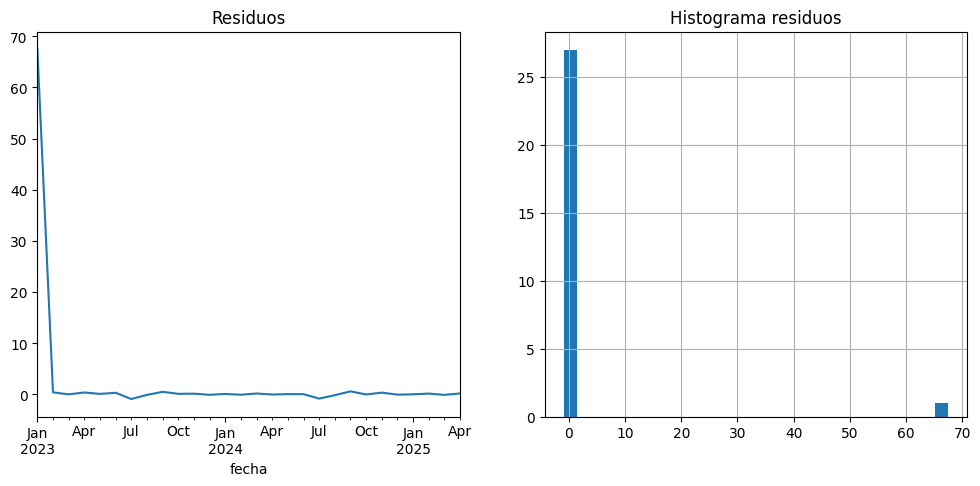

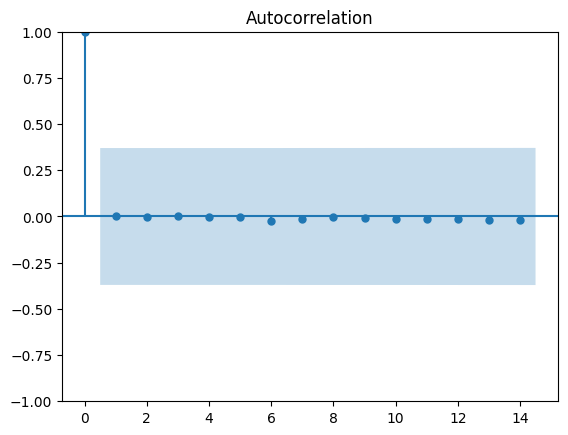

count    28.000000
mean      2.461073
std      12.750410
min      -0.900347
25%      -0.047362
50%       0.074239
75%       0.219442
max      67.500000
dtype: float64

In [21]:
residuos = st.analizar_residuos(
    modelo_arima_opt
)

residuos.describe()


Hallazgos

El análisis de residuos muestra que los errores del modelo permanecen próximos a cero y no presentan patrones temporales evidentes.

La función de autocorrelación de los residuos no muestra picos significativos, indicando ausencia de dependencia temporal residual.

Se detecta un valor atípico muy elevado en el primer residuo, posiblemente derivado del proceso de inicialización interna del modelo ARIMA.

Conclusiones

Una vez ignorado el efecto del primer residuo, el comportamiento de los errores resulta compatible con ruido blanco.

Esto sugiere que el modelo ARIMA(2,1,2) ha capturado adecuadamente la información temporal disponible en la serie y que no quedan patrones relevantes sin modelar.

### 9. Forecast futuro

¿Qué pasará durante 2026?

In [22]:
modelo_final = st.entrenar_arima(
    serie,
    order=(2,1,2)
)

forecast_12 = st.forecast(
    modelo_final,
    pasos=12
)

forecast_12

c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\equipo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2026-01-01    82.126432
2026-02-01    82.548793
2026-03-01    82.933178
2026-04-01    83.332590
2026-05-01    83.726050
2026-06-01    84.121860
2026-07-01    84.516735
2026-08-01    84.911975
2026-09-01    85.307065
2026-10-01    85.702210
2026-11-01    86.097328
2026-12-01    86.492452
Freq: MS, Name: predicted_mean, dtype: float64

 Forecast futuro (2026)

Se utiliza el modelo ARIMA(2,1,2) optimizado para generar una predicción de los 12 meses posteriores al periodo observado.

Hallazgos

La predicción mantiene una tendencia ascendente a lo largo de todo el año 2026.

La nota media esperada evoluciona desde aproximadamente 82.1 puntos en enero hasta 86.5 puntos en diciembre.

Conclusión

Según el modelo entrenado, el rendimiento académico medio continuará mejorando durante 2026.

La evolución prevista es consistente con la tendencia creciente observada en los datos históricos.